# Practical 02 — Covariance, Pearson Correlation, and the Variance–Covariance Matrix

**Laboratory:** M.Tech Machine Learning  
**Kernel:** `ml-lab-kernel`  
**Datasets:** Iris (`data/iris.csv`), Auto MPG (`data/auto_mpg.csv`)

### Lab map

```text
[1] Colab header  →  [2] DATASET CONFIG (path + numeric features)
        ↓
[3] Load tables  →  [4] MANUAL worked example (means → r)
        ↓
[5] Matrix form S = X̃ᵀX̃ / (n−1)  →  [6] Plots (+r / −r / 0, heatmap, pairplot)
        ↓
[7] Viva Q&A  →  [8] Conclusion
```

### Learning outcomes

1. Compute **sample covariance** with Bessel’s correction $n-1$ by hand.
2. Convert covariance into **Pearson** $r \in [-1,1]$.
3. Build the **variance–covariance matrix** $\mathbf{S}$ and **correlation matrix** $\mathbf{R}$.
4. Match the hand table against **NumPy / Pandas**.
5. Read **$+r$**, **$-r$**, and **$r \approx 0$** from scatter plots — without claiming causation.

> **Why this matters:** covariance and $r$ are the language of PCA, Mahalanobis distance, and almost every linear model. If you mix up $n$ vs $n-1$, or treat $r=0$ as independence, later labs will mislead you.


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or run this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or mount Drive and set `COLAB_DRIVE_CSV`.
3. No file: loaders fall back to a public URL / sklearn.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime; packages should already be installed.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, Markdown, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#0f766e") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _why(text: str) -> None:
    display(
        HTML(
            f'<div style="background:#ecfeff;border-left:4px solid #0e7490;'
            f"padding:10px 14px;border-radius:4px;font-family:Segoe UI,sans-serif;"
            f'margin:8px 0;"><b>Why this matters.</b> {text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )  # why: Colab VMs start empty; campus PCs already have the lab venv
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    """1-click CSV upload on Colab."""
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()  # why: Colab has no ./data folder until you add one
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")  # why: reuse a CSV already stored in Drive
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — the only cell most beginners edit

```text
  DATA_PATH ──► CSV on disk
  NUMERIC_FEATURES ──► which columns enter S and R  (None = all numeric except target)
  TARGET_COLUMN ──► optional label (species) for colouring pairplots; not used in cov
  DROP_COLUMNS ──► IDs / names to ignore
```

**Lab default:** Iris. To study engines instead, set `DATA_PATH = "data/auto_mpg.csv"` and pick numeric columns such as `["mpg", "horsepower", "weight"]`.

> **Why this matters:** covariance is only defined for **numbers**. If you leave a text column in, Pandas will skip it or crash. Naming features here is safer than hunting through later cells.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — edit this block to swap CSV / numeric features     ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = "data/iris.csv"          # why: primary table for S, R, heatmap, pairplot
TARGET_COLUMN = "species"            # why: colour the pairplot; excluded from covariance
DROP_COLUMNS: list[str] = []         # why: drop IDs/names before any numeric work
# None → every numeric column except TARGET_COLUMN. Or list names explicitly:
NUMERIC_FEATURES: list[str] | None = None  # e.g. ["petal_length_cm", "petal_width_cm"]

MPG_PATH = "data/auto_mpg.csv"       # why: second lab table (weight vs mpg = classic −r)

# Colab-only (ignored locally)
COLAB_DRIVE_CSV = None               # e.g. "/content/drive/MyDrive/iris.csv"
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

_rule("DATASET CONFIG")
print(f"DATA_PATH         = {DATA_PATH}")
print(f"TARGET_COLUMN     = {TARGET_COLUMN}")
print(f"DROP_COLUMNS      = {DROP_COLUMNS}")
print(f"NUMERIC_FEATURES  = {NUMERIC_FEATURES}  (None = auto numeric)")
print(f"MPG_PATH          = {MPG_PATH}")
_p = _Path(DATA_PATH)
print(f"local primary CSV exists: {_p.is_file()}  ({_p.resolve() if _p.exists() else _p})")



 DATASET CONFIG
DATA_PATH         = data/iris.csv
TARGET_COLUMN     = species
DROP_COLUMNS      = []
NUMERIC_FEATURES  = None  (None = auto numeric)
MPG_PATH          = data/auto_mpg.csv
local primary CSV exists: True  (D:\LiamCodes\parul-mtech-coding\ml-practical\02_Covariance_Correlation\data\iris.csv)


## 0. Environment, seed, and large high-DPI figures

> **Why this matters:** one seed makes your numbers match a lab partner. Pinning figure size/DPI once makes every plot readable on a projector and in a PDF record.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_iris

SEED = 42  # why: any fixed int is fine; 42 is the lab convention
np.random.seed(SEED)

plt.rcParams.update(
    {
        "figure.figsize": (14, 7),  # why: large on-screen / projection figures
        "figure.dpi": 140,          # why: sharp saved notebook outputs
        "savefig.dpi": 300,         # why: print-quality PNG/PDF
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,         # why: light grid; points stay the focus
    }
)
pd.set_option("display.max_columns", 25)  # why: wide tables stay readable
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 48)
sns.set_theme(style="whitegrid", palette="colorblind")  # why: colourblind-safer hues

_banner("0 · Libraries")
print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)
print("SEED =", SEED)


Python 3.14.0
numpy 2.5.2 | pandas 3.0.5 | seaborn 0.13.2
SEED = 42


## 1. Load the configured table (local → URL → sklearn)

| Priority | Primary (`DATA_PATH`) | Auto MPG |
|----------|----------------------|----------|
| 1 | local path from CONFIG | `MPG_PATH` |
| 2 | seaborn-data Iris URL (if path looks like iris) | Plotly auto-mpg URL |
| 3 | `sklearn.datasets.load_iris` | (raise after URL failure) |


In [4]:
IRIS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
MPG_URL = "https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv"


def _iris_from_sklearn() -> pd.DataFrame:
    bunch = load_iris(as_frame=True)  # why: last-resort if disk and URL both fail
    frame = bunch.frame.copy()
    frame.columns = [
        "sepal_length_cm",
        "sepal_width_cm",
        "petal_length_cm",
        "petal_width_cm",
        "species",
    ]
    frame["species"] = frame["species"].map(dict(enumerate(bunch.target_names)))
    return frame


def _harmonize_iris(frame: pd.DataFrame) -> pd.DataFrame:
    rename = {
        "sepal_length": "sepal_length_cm",
        "sepal_width": "sepal_width_cm",
        "petal_length": "petal_length_cm",
        "petal_width": "petal_width_cm",
        "sepal.length": "sepal_length_cm",
        "sepal.width": "sepal_width_cm",
        "petal.length": "petal_length_cm",
        "petal.width": "petal_width_cm",
    }
    return frame.rename(columns={k: v for k, v in rename.items() if k in frame.columns})


def load_primary() -> tuple[pd.DataFrame, str]:
    path = Path(DATA_PATH)
    if IN_COLAB and COLAB_DRIVE_CSV:
        colab_mount_drive()
        drive_p = Path(COLAB_DRIVE_CSV)
        if drive_p.is_file():
            return pd.read_csv(drive_p), "gdrive"
    if IN_COLAB and COLAB_OFFER_UPLOAD and not path.is_file():
        saved = colab_upload_to(path)
        if saved is not None:
            return pd.read_csv(saved), "colab_upload"
    if path.is_file():
        df_local = pd.read_csv(path)  # why: lab machines ship a version-controlled CSV
        return _harmonize_iris(df_local), "local"
    try:
        return _harmonize_iris(pd.read_csv(IRIS_URL)), "url"
    except Exception as exc:
        print("URL failed:", type(exc).__name__, exc)
        return _iris_from_sklearn(), "sklearn"


def load_mpg() -> tuple[pd.DataFrame, str]:
    p = Path(MPG_PATH)
    if p.is_file():
        return pd.read_csv(p), "local"
    return pd.read_csv(MPG_URL), "url"


df, load_origin = load_primary()
mpg, mpg_origin = load_mpg()

for col in DROP_COLUMNS:
    if col in df.columns:
        df = df.drop(columns=[col])  # why: IDs must not enter covariance

if TARGET_COLUMN and TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"TARGET_COLUMN={TARGET_COLUMN!r} not in {list(df.columns)}. "
        "Fix the CONFIG cell."
    )

num_cols = list(df.select_dtypes(include=[np.number]).columns)
if TARGET_COLUMN in num_cols:
    num_cols = [c for c in num_cols if c != TARGET_COLUMN]
if NUMERIC_FEATURES is None:
    feature_cols = num_cols
else:
    missing = [c for c in NUMERIC_FEATURES if c not in df.columns]
    if missing:
        raise KeyError(f"NUMERIC_FEATURES not in CSV: {missing}. Columns: {list(df.columns)}")
    feature_cols = list(NUMERIC_FEATURES)

_banner("1 · Loaded tables")
print(f"primary origin = {load_origin} | shape = {df.shape} | cols = {list(df.columns)}")
print(f"numeric features used in S, R = {feature_cols}")
print(f"MPG origin = {mpg_origin} | shape = {mpg.shape} | cols = {list(mpg.columns)}")
display(df.head(5).style.set_caption("Primary table (first 5 rows)").format(precision=3))


primary origin = local | shape = (150, 5) | cols = ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'species']
numeric features used in S, R = ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']
MPG origin = local | shape = (398, 7) | cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model-year']


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


## 2. Step-by-step manual calculation (lab-manual standard)

We use a **tiny integer table** so every arithmetic step fits on one page. This is *not* Iris — it is a calculator exercise you can repeat in an exam.

| $i$ | $x_i$ | $y_i$ |
|----:|------:|------:|
| 1 | 1 | 2 |
| 2 | 2 | 4 |
| 3 | 3 | 5 |
| 4 | 4 | 4 |
| 5 | 5 | 5 |

### Recipe (write this in the lab record)

1. **Means**
   $$
   \bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i,\qquad
   \bar{y}=\frac{1}{n}\sum_{i=1}^{n}y_i.
   $$
2. **Deviations** $d_{x,i}=x_i-\bar{x}$, $d_{y,i}=y_i-\bar{y}$.
3. **Products of deviations** $d_{x,i}\,d_{y,i}$.
4. **Sums of squares / products**
   $$
   \mathrm{SS}_x=\sum d_{x,i}^{2},\quad
   \mathrm{SS}_y=\sum d_{y,i}^{2},\quad
   \mathrm{SP}_{xy}=\sum d_{x,i}\,d_{y,i}.
   $$
5. **Sample covariance** (divide by $n-1$, **not** $n$)
   $$
   s_{xy}=\frac{\mathrm{SP}_{xy}}{n-1}.
   $$
6. **Pearson** $r$ ($n-1$ cancels)
   $$
   r_{xy}
   =\frac{\mathrm{SP}_{xy}}{\sqrt{\mathrm{SS}_x\,\mathrm{SS}_y}}
   =\frac{s_{xy}}{s_x s_y}.
   $$

> **Why this matters:** $n-1$ is one degree of freedom spent on the sample mean. Pandas `DataFrame.cov` and `np.cov(..., ddof=1)` use the same convention. Mixing $n$ and $n-1$ is a classic viva trap.


In [5]:
_banner("2 · Manual worked example")

x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])  # why: small integers so the table is exam-friendly
y = np.array([2.0, 4.0, 5.0, 4.0, 5.0])
n = len(x)  # why: n=5 pairs

xbar = x.mean()  # why: mean uses n, not n-1
ybar = y.mean()
dx = x - xbar
dy = y - ybar
prod = dx * dy
ssx = np.sum(dx**2)
ssy = np.sum(dy**2)
sp = np.sum(prod)

s_xy = sp / (n - 1)  # why: Bessel correction — unbiased sample covariance
s_x = np.sqrt(ssx / (n - 1))
s_y = np.sqrt(ssy / (n - 1))
r_hand = sp / np.sqrt(ssx * ssy)  # why: n-1 cancels; equivalent to s_xy / (s_x s_y)

work = pd.DataFrame(
    {
        "i": np.arange(1, n + 1),
        "x": x,
        "y": y,
        "d_x = x - x̄": dx,
        "d_y = y - ȳ": dy,
        "d_x · d_y": prod,
        "d_x²": dx**2,
        "d_y²": dy**2,
    }
)

_why(
    "If every product of deviations is positive, both variables lie on the same side of "
    "their means together → covariance (and r) is positive. Mixed signs pull r toward zero or negative."
)

display(
    work.style.format(precision=3)
    .background_gradient(subset=["d_x · d_y"], cmap="coolwarm")
    .set_caption("Worked table: means → deviations → products → squares")
)

summary = pd.DataFrame(
    {
        "quantity": [
            "n",
            "x̄",
            "ȳ",
            "SS_x = Σ d_x²",
            "SS_y = Σ d_y²",
            "SP_xy = Σ d_x d_y",
            "s_xy = SP / (n−1)",
            "s_x",
            "s_y",
            "r (hand)",
        ],
        "value": [n, xbar, ybar, ssx, ssy, sp, s_xy, s_x, s_y, r_hand],
    }
)
display(summary.style.format({"value": "{:.6f}"}).set_caption("Totals used in the lab record"))

toy = pd.DataFrame({"x": x, "y": y})
r_np = float(np.corrcoef(x, y)[0, 1])  # why: [0,1] is the off-diagonal of the 2×2 matrix
r_pd = float(toy["x"].corr(toy["y"]))  # why: Series.corr is Pearson by default
s_np = float(np.cov(x, y, ddof=1)[0, 1])  # why: ddof=1 → divide by n-1
s_pd = float(toy["x"].cov(toy["y"]))  # why: Pandas cov also uses n-1

check = pd.DataFrame(
    {
        "estimator": ["sample covariance s_xy", "Pearson r"],
        "hand": [s_xy, r_hand],
        "numpy": [s_np, r_np],
        "pandas": [s_pd, r_pd],
        "max |hand − library|": [
            max(abs(s_xy - s_np), abs(s_xy - s_pd)),
            max(abs(r_hand - r_np), abs(r_hand - r_pd)),
        ],
    }
)
display(
    check.style.format(precision=8).set_caption(
        "Verification: hand arithmetic vs NumPy / Pandas (should be ~ 0 difference)"
    )
)
assert np.allclose(s_xy, s_np) and np.allclose(r_hand, r_np)
print("Hand calculation MATCHES NumPy and Pandas (n−1 convention).")


,i,x,y,d_x = x - x̄,d_y = y - ȳ,d_x · d_y,d_x²,d_y²
0,1,1.000,2.000,-2.000,-2.000,4.000,4.000,4.000
1,2,2.000,4.000,-1.000,0.000,-0.000,1.000,0.000
2,3,3.000,5.000,0.000,1.000,0.000,0.000,1.000
3,4,4.000,4.000,1.000,0.000,0.000,1.000,0.000
4,5,5.000,5.000,2.000,1.000,2.000,4.000,1.000


,quantity,value
0,n,5.000000
1,x̄,3.000000
2,ȳ,4.000000
3,SS_x = Σ d_x²,10.000000
4,SS_y = Σ d_y²,6.000000
5,SP_xy = Σ d_x d_y,6.000000
6,s_xy = SP / (n−1),1.500000
7,s_x,1.581139
8,s_y,1.224745
9,r (hand),0.774597


,estimator,hand,numpy,pandas,max |hand − library|
0,sample covariance s_xy,1.50000000,1.50000000,1.50000000,0.00000000
1,Pearson r,0.77459667,0.77459667,0.77459667,0.00000000


Hand calculation MATCHES NumPy and Pandas (n−1 convention).


## 3. Vectorized matrix form (what libraries actually compute)

After centering every column (subtract the column mean), the whole covariance matrix is **one** product:

```text
  Data X (n × p)          Centered X̃              Gram / (n−1)
  rows = students         each column has           S is p × p
  cols = features         mean 0

      [ x11 x12 … ]          [ d11 d12 … ]
      [ x21 x22 … ]   →      [ d21 d22 … ]     S = (X̃ᵀ X̃) / (n−1)
      [  ⋮   ⋮    ]          [  ⋮   ⋮    ]
```

$$
\tilde{X} = X - \mathbf{1}\bar{\mathbf{x}}^{\top},
\qquad
\mathbf{S}
= \frac{1}{n-1}\,\tilde{X}^{\top}\tilde{X}
\in \mathbb{R}^{p \times p}.
$$

**How to read $\mathbf{S}$**

```text
          feat 1     feat 2     feat 3
feat 1   variance    cov12      cov13      ← diagonal = variances (never negative)
feat 2   cov12       variance   cov23      ← S is SYMMETRIC (cov12 = cov21)
feat 3   cov13       cov23      variance
```

**Correlation matrix** (scale-invariant): divide each covariance by the two standard deviations.

$$
\mathbf{R}
= D^{-1/2}\,\mathbf{S}\,D^{-1/2},
\quad
D=\operatorname{diag}(\mathbf{S}),
\quad
R_{jk}=\frac{S_{jk}}{\sqrt{S_{jj}S_{kk}}},
\quad
R_{jj}=1.
$$

```text
R looks like S, but every diagonal is 1, and every off-diagonal is a Pearson r in [-1, 1].
Changing cm → mm (multiply a column by 10) CHANGES S, but R stays the same.
```

> **Why this matters:** PCA eigendecomposes $\mathbf{S}$ (or $\mathbf{R}$ if you standardise first). If you forget to centre, $\tilde{X}^{\top}\tilde{X}$ is the wrong Gram matrix.


In [6]:
_banner("3 · S and R from the configured numeric features")

X = df[feature_cols].to_numpy(dtype=np.float64)  # why: matrix algebra needs a numeric ndarray
n_obs, p = X.shape
X_tilde = X - X.mean(axis=0, keepdims=True)  # why: keepdims so (n,p) minus (1,p) broadcasts
S_vec = (X_tilde.T @ X_tilde) / (n_obs - 1)  # why: the formula in the markdown above
S_pd = df[feature_cols].cov(ddof=1)  # why: ddof=1 matches the lab's n-1

std = np.sqrt(np.diag(S_vec))  # why: column stds with the same n-1 as S
R_vec = S_vec / np.outer(std, std)  # why: R_jk = S_jk / (s_j s_k); diagonal becomes 1
R_pd = df[feature_cols].corr()  # why: Pearson; pairwise complete columns

_why(
    f"S is {p}×{p} and symmetric. Diagonal entries are variances in the original units "
    f"(cm² for Iris lengths). R is the same shape but unitless."
)

display(
    pd.DataFrame(S_vec, index=feature_cols, columns=feature_cols)
    .style.format("{:.4f}")
    .background_gradient(cmap="YlOrRd")
    .set_caption(r"S = X̃ᵀX̃ / (n−1)  — sample covariance (vectorized)")
)
display(
    S_pd.style.format("{:.4f}").set_caption("Pandas DataFrame.cov(ddof=1) — must match S")
)
display(
    pd.DataFrame(R_vec, index=feature_cols, columns=feature_cols)
    .style.format("{:.3f}")
    .background_gradient(cmap="coolwarm", vmin=-1, vmax=1)
    .set_caption("R — Pearson correlation (from S); diagonal = 1")
)

print("max |S_vec − S_pandas| =", np.nanmax(np.abs(S_vec - S_pd.to_numpy())))
print("max |R_vec − R_pandas| =", np.nanmax(np.abs(R_vec - R_pd.to_numpy())))
print("S symmetric?", np.allclose(S_vec, S_vec.T))
print("R diagonal ~ 1?", np.allclose(np.diag(R_vec), 1.0))


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
sepal_length_cm,0.6857,-0.0424,1.2743,0.5163
sepal_width_cm,-0.0424,0.1900,-0.3297,-0.1216
petal_length_cm,1.2743,-0.3297,3.1163,1.2956
petal_width_cm,0.5163,-0.1216,1.2956,0.5810


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
sepal_length_cm,0.6857,-0.0424,1.2743,0.5163
sepal_width_cm,-0.0424,0.1900,-0.3297,-0.1216
petal_length_cm,1.2743,-0.3297,3.1163,1.2956
petal_width_cm,0.5163,-0.1216,1.2956,0.5810


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
sepal_length_cm,1.000,-0.118,0.872,0.818
sepal_width_cm,-0.118,1.000,-0.428,-0.366
petal_length_cm,0.872,-0.428,1.000,0.963
petal_width_cm,0.818,-0.366,0.963,1.000


max |S_vec − S_pandas| = 0.0
max |R_vec − R_pandas| = 1.3322676295501878e-15
S symmetric? True
R diagonal ~ 1? True


## 4. Publication-quality figures

### 4.1 Three clouds: $+r$, $-r$, and $r \approx 0$

Each panel is synthetic ($n=80$) so the geometry is obvious. A **dashed OLS trendline** is $\hat{y}=a+bx$.

> **Why this matters:** the *sign* of $r$ is the slope of that line. A round blob with a flat line is “no **linear** association” — a U-shape can still hide a nonlinear relationship with $r\approx 0$.


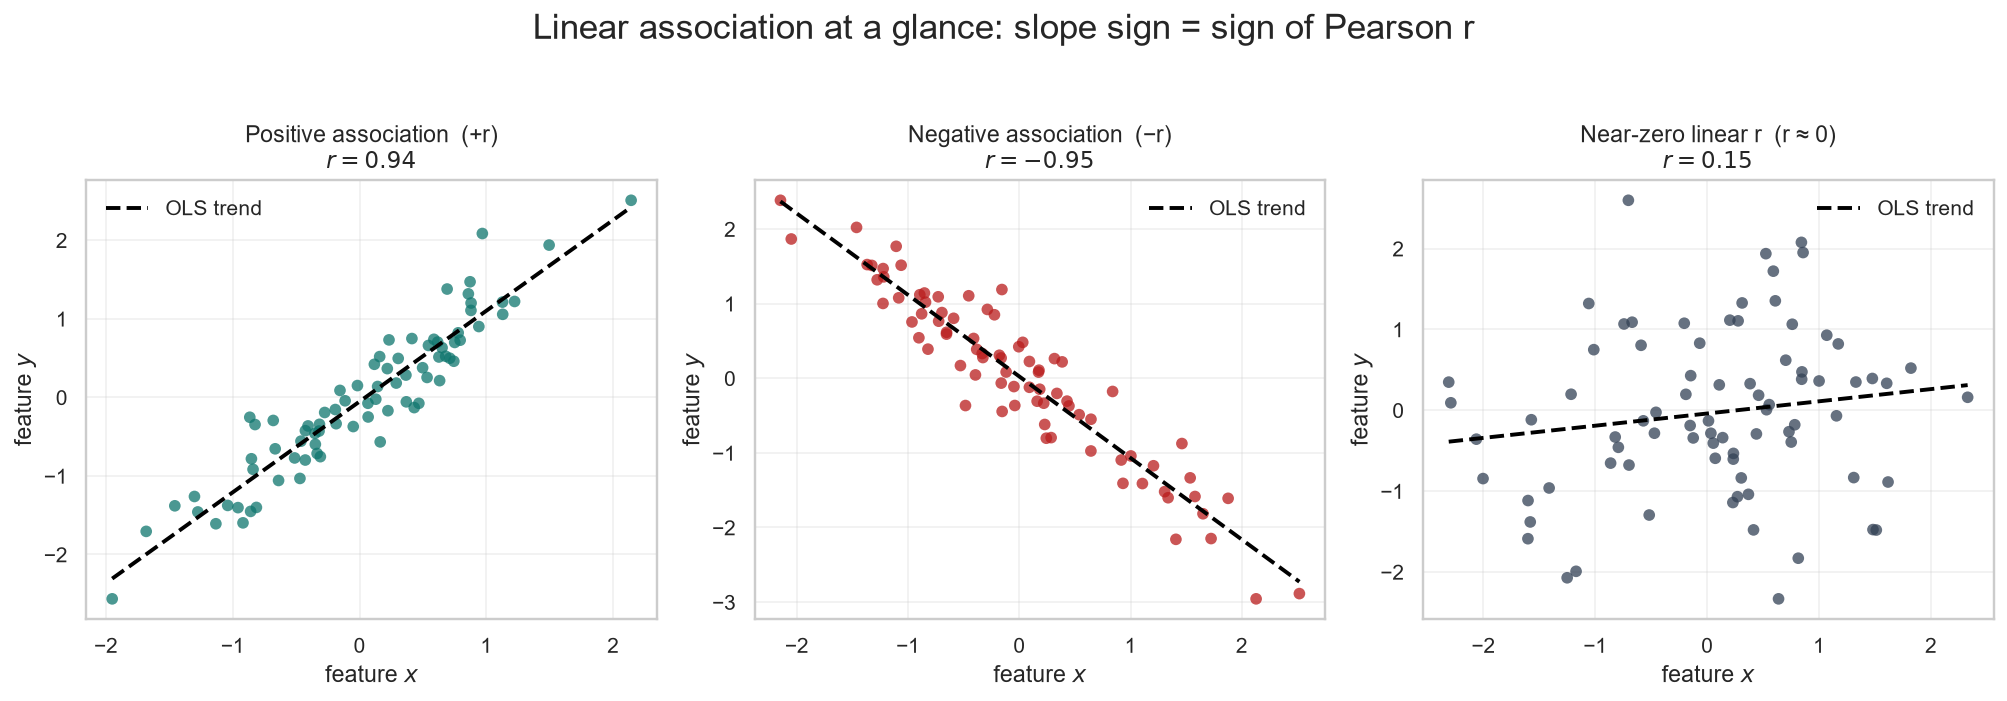

In [7]:
_banner("4.1 · Three-panel scatter (+r / −r / 0)")

rng = np.random.default_rng(SEED)
n_cloud = 80  # why: enough points to see the cloud without a solid smear

x_pos = rng.normal(0.0, 1.0, n_cloud)
y_pos = 1.1 * x_pos + rng.normal(0.0, 0.35, n_cloud)  # why: same-direction noise → +r

x_neg = rng.normal(0.0, 1.0, n_cloud)
y_neg = -1.1 * x_neg + rng.normal(0.0, 0.35, n_cloud)  # why: opposite slope → −r

x_zero = rng.normal(0.0, 1.0, n_cloud)
y_zero = rng.normal(0.0, 1.0, n_cloud)  # why: independent Gaussians → r ≈ 0

panels = [
    (x_pos, y_pos, "Positive association  (+r)", "#0f766e"),
    (x_neg, y_neg, "Negative association  (−r)", "#b91c1c"),
    (x_zero, y_zero, "Near-zero linear r  (r ≈ 0)", "#334155"),
]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), sharey=False)
for ax, (xs, ys, title, color) in zip(axes, panels):
    r_val = float(np.corrcoef(xs, ys)[0, 1])
    ax.scatter(xs, ys, s=36, alpha=0.75, c=color, edgecolors="none")  # why: alpha shows overlap
    coef = np.polyfit(xs, ys, deg=1)  # why: degree 1 = OLS straight line
    xline = np.linspace(xs.min(), xs.max(), 50)
    ax.plot(xline, np.polyval(coef, xline), ls="--", lw=2, c="black", label="OLS trend")
    ax.set_title(f"{title}\n$r={r_val:.2f}$")
    ax.set_xlabel("feature $x$")
    ax.set_ylabel("feature $y$")
    ax.legend(frameon=False, loc="best")

fig.suptitle("Linear association at a glance: slope sign = sign of Pearson r", y=1.04)
fig.tight_layout()
plt.show()


### 4.2 Annotated correlation heatmap (`coolwarm`, locked to $[-1,1]$)

```text
  colour key   −1  red     0  white     +1  blue
               opposite           none            same direction
```

> **Why this matters:** without `vmin=-1` and `vmax=1`, a lab with only $r\in[0.6,1]$ would paint everything “hot” and hide that nothing is negatively associated.


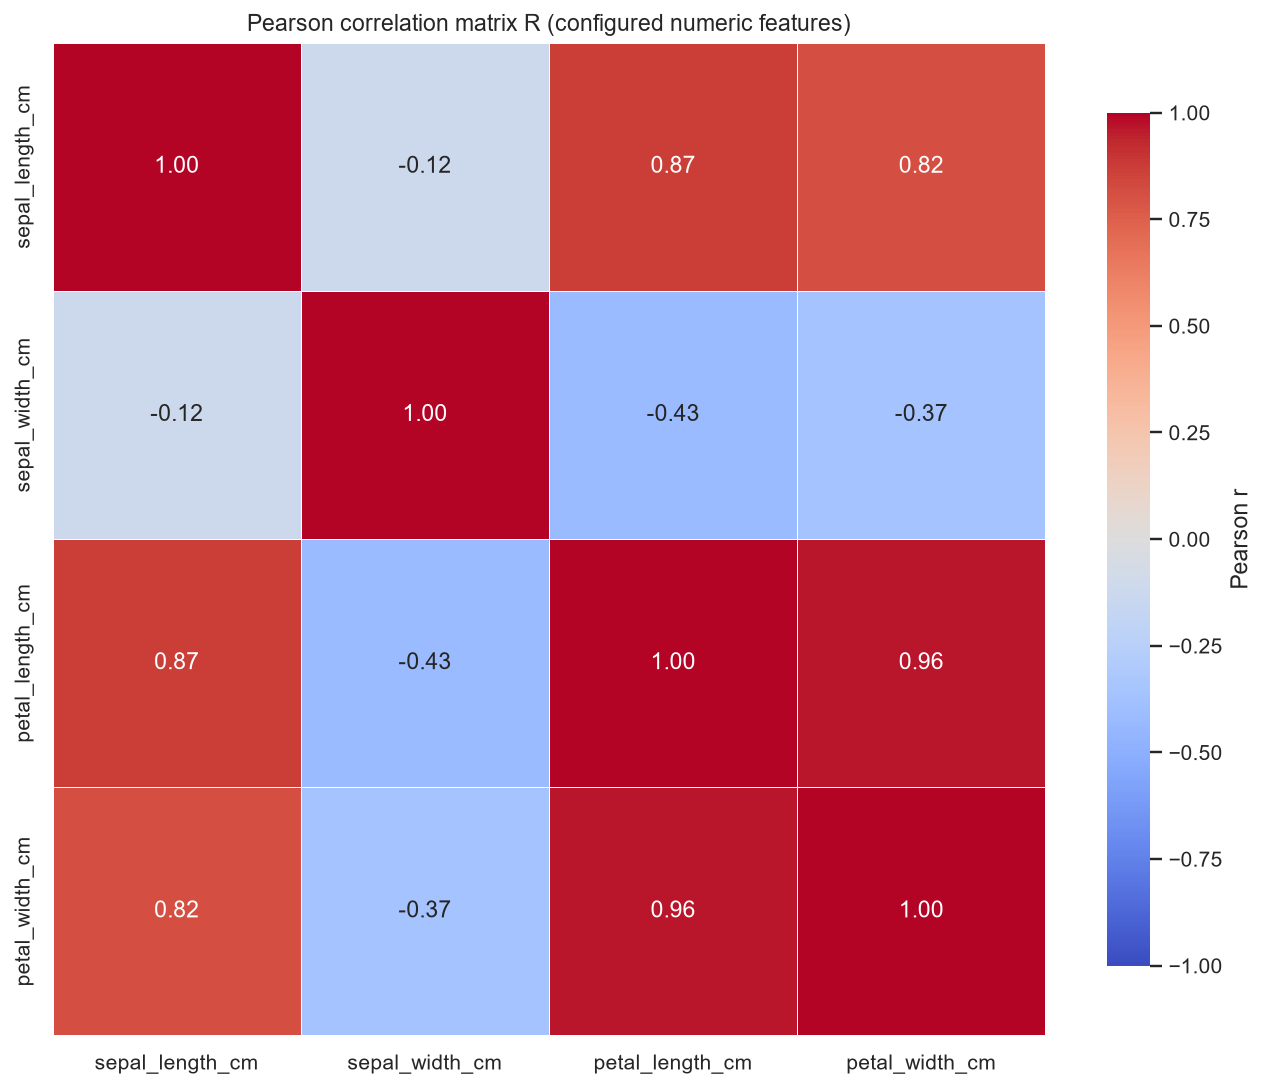

In [8]:
_banner("4.2 · Correlation heatmap (primary table)")

fig, ax = plt.subplots(figsize=(9.5, 8.0))
sns.heatmap(
    R_pd,
    ax=ax,
    cmap="coolwarm",   # why: diverging — red vs blue, not a rainbow
    vmin=-1,           # why: lock the colour scale to the true range of r
    vmax=1,
    center=0,          # why: white = no linear association
    annot=True,        # why: print the number in each cell for the lab record
    fmt=".2f",
    square=True,       # why: covariance/correlation matrices are square
    linewidths=0.4,
    cbar_kws={"shrink": 0.82, "label": "Pearson r"},
)
ax.set_title("Pearson correlation matrix R (configured numeric features)")
fig.tight_layout()
plt.show()


### 4.3 Pairplot — every numeric pair at once

Diagonal = distribution of one feature. Off-diagonal = scatter of two features (hue = `TARGET_COLUMN` if it exists).

> **Why this matters:** a single $r$ cannot show **clusters** (Iris species). The pairplot is where you see that petal length vs petal width is tight *and* separated by species.


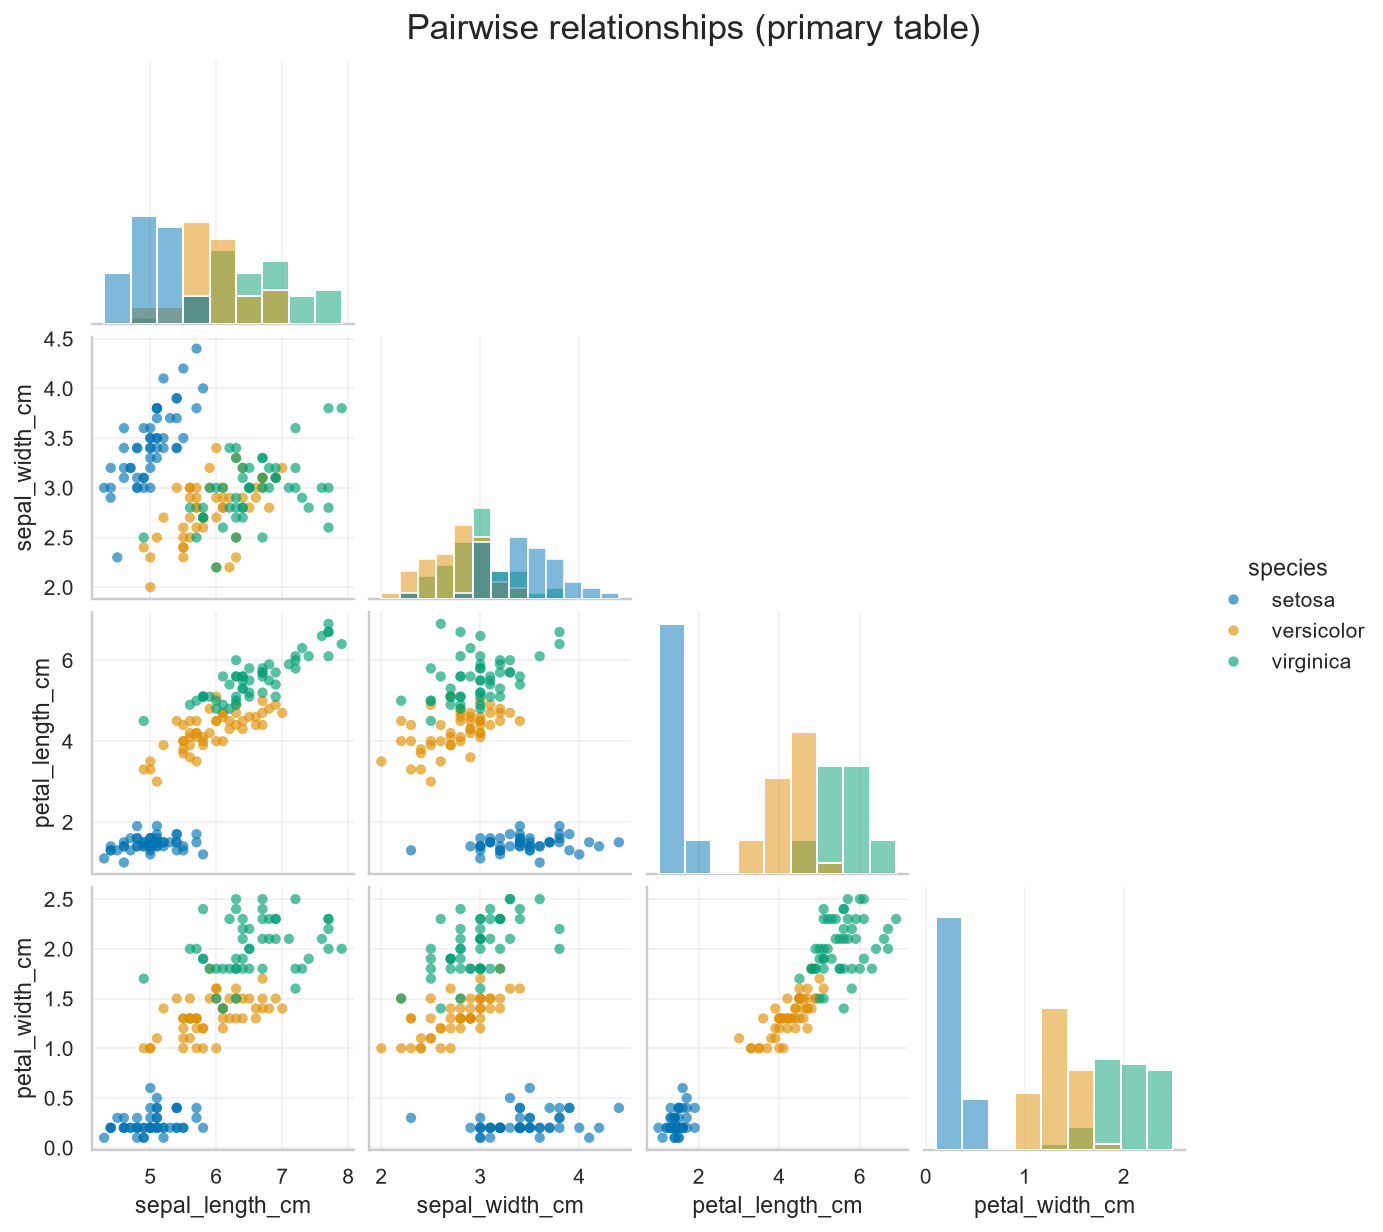

In [9]:
_banner("4.3 · Pairplot")

pair_cols = feature_cols[:5]  # why: pairplot is O(p²) panels — keep p small
hue = TARGET_COLUMN if TARGET_COLUMN in df.columns else None
g = sns.pairplot(
    df[pair_cols + ([hue] if hue else [])],
    hue=hue,
    corner=True,          # why: skip the duplicate upper triangle
    diag_kind="hist",
    plot_kws={"alpha": 0.65, "s": 28, "edgecolor": "none"},
    height=2.15,          # why: each panel large enough to read ticks
)
g.fig.suptitle("Pairwise relationships (primary table)", y=1.02)
plt.show()


### 4.4 Real-world negative $r$: car weight vs MPG

Heavier cars tend to use more fuel, so **MPG falls** as **weight** rises — a textbook negative association.


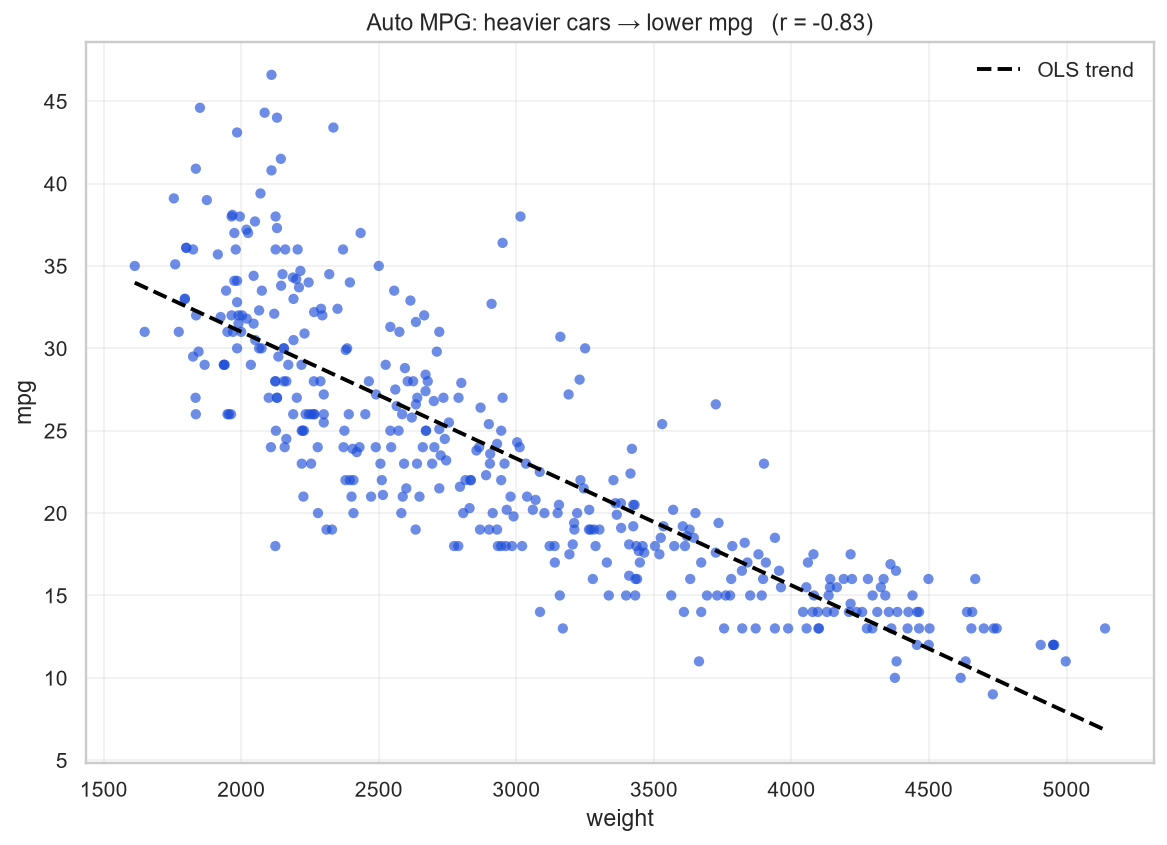

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
mpg,1.00,-0.78,-0.80,-0.78,-0.83,0.42,0.58
cylinders,-0.78,1.00,0.95,0.84,0.90,-0.50,-0.35
displacement,-0.80,0.95,1.00,0.90,0.93,-0.54,-0.37
horsepower,-0.78,0.84,0.90,1.00,0.86,-0.69,-0.42
weight,-0.83,0.90,0.93,0.86,1.00,-0.42,-0.31
acceleration,0.42,-0.50,-0.54,-0.69,-0.42,1.00,0.29
model-year,0.58,-0.35,-0.37,-0.42,-0.31,0.29,1.00


In [10]:
_banner("4.4 · Auto MPG: weight vs mpg")

mpg_num = mpg.select_dtypes(include=[np.number]).dropna()
x_w = mpg_num["weight"].to_numpy()
y_m = mpg_num["mpg"].to_numpy()
r_mpg = float(np.corrcoef(x_w, y_m)[0, 1])

fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.scatter(x_w, y_m, s=28, alpha=0.65, c="#1d4ed8", edgecolors="none")
coef = np.polyfit(x_w, y_m, deg=1)
xs = np.linspace(x_w.min(), x_w.max(), 80)
ax.plot(xs, np.polyval(coef, xs), ls="--", c="black", lw=2, label="OLS trend")
ax.set_xlabel("weight")
ax.set_ylabel("mpg")
ax.set_title(f"Auto MPG: heavier cars → lower mpg   (r = {r_mpg:.2f})")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

display(
    mpg_num.corr()
    .style.format("{:.2f}")
    .background_gradient(cmap="coolwarm", vmin=-1, vmax=1)
    .set_caption("Auto MPG Pearson R (numeric columns)")
)


## 5. Viva-voce (indicative Q&A)

**Q1. Write the sample covariance formula. Why $n-1$?**  
**A.** $s_{xy}=\frac{1}{n-1}\sum_i(x_i-\bar{x})(y_i-\bar{y})$. One degree of freedom is used up by estimating the means. $n$ gives the Gaussian MLE (biased low). Pandas/NumPy default to $n-1$ (`ddof=1`).

**Q2. How is Pearson $r$ obtained from covariance?**  
**A.** $r=s_{xy}/(s_x s_y)=\mathrm{SP}_{xy}/\sqrt{\mathrm{SS}_x\mathrm{SS}_y}$. The $n-1$ cancels. $|r|\le 1$ by Cauchy–Schwarz.

**Q3. State $\mathbf{S}$ in matrix form.**  
**A.** With centered data $\tilde{X}=X-\mathbf{1}\bar{x}^{\top}$, $\mathbf{S}=\tilde{X}^{\top}\tilde{X}/(n-1)$. Symmetric, PSD, diagonal = variances.

**Q4. How do you get $\mathbf{R}$ from $\mathbf{S}$?**  
**A.** $R_{jk}=S_{jk}/\sqrt{S_{jj}S_{kk}}$. Equivalently $R=D^{-1/2}SD^{-1/2}$ with $D=\mathrm{diag}(S)$. Diagonals of $R$ are $1$.

**Q5. Covariance depends on units; $r$ does not. Explain.**  
**A.** If $x'=c_x x+b_x$ and $y'=c_y y+b_y$ with $c_x c_y>0$, then $s_{x'y'}=c_x c_y s_{xy}$ but $r_{x'y'}=r_{xy}$. Measuring length in mm vs cm changes $S$, not $R$.

**Q6. Does $r=0$ prove $X$ and $Y$ are independent?**  
**A.** No. $r$ only sees **linear** association. A parabola can have $r\approx 0$. Independence $\Rightarrow r=0$ (when variances exist), not the converse.

**Q7. Does a large $|r|$ prove causation?**  
**A.** No. Confounders (species in Iris; engine size in cars) can induce correlation.

**Q8. Why `vmin=-1`, `vmax=1`, `center=0` on a heatmap?**  
**A.** So colour encodes the true range of $r$. Otherwise a matrix of only large positive $r$ looks uniformly “hot”.

**Q9. What is `ddof` in `np.cov` / `np.std`?**  
**A.** Divisor is $n-\mathrm{ddof}$. Sample convention: `ddof=1`. Population / MLE: `ddof=0`.

**Q10. Why centre columns before $\tilde{X}^{\top}\tilde{X}$?**  
**A.** Without subtracting means you compute a raw second-moment matrix, not covariance.

**Q11. Iris petal length vs petal width is strongly positive. Interpret.**  
**A.** Flowers with longer petals tend to have wider petals (same biology, three species clusters). Still not “length causes width”.

**Q12. Auto MPG vs weight is negative. Interpret.**  
**A.** Heavier vehicles tend to travel fewer miles per gallon. Linear trend is strong but not a physical identity (gearing, aerodynamics also matter).


## 6. Conclusion

This practical locked in the **lab-manual pipeline** for association:

1. **CONFIG first** — `DATA_PATH`, `NUMERIC_FEATURES`, `TARGET_COLUMN`, `DROP_COLUMNS`.
2. **Hand table** — means → deviations → products → $\mathrm{SS}$/$\mathrm{SP}$ → $s_{xy}$ with $n-1$ → Pearson $r$, checked against NumPy/Pandas.
3. **Matrices** — $\mathbf{S}=\tilde{X}^{\top}\tilde{X}/(n-1)$ (symmetric, variances on the diagonal) and scale-free $\mathbf{R}$.
4. **Pictures** — $+r$/$-r$/$0$ scatter with trendlines, `coolwarm` heatmap locked to $[-1,1]$, pairplot, and a real negative $r$ (weight vs mpg).

**Next practical:** linear regression treats $r$ as a hint, then estimates a slope and residual error — still without touching `extra/`.

### Submission checklist

- [ ] Re-run all cells top-to-bottom on `ml-lab-kernel`
- [ ] Paste the worked table totals ($\bar{x},\bar{y},\mathrm{SP},s_{xy},r$) in the lab record
- [ ] Record `load_origin` and which `NUMERIC_FEATURES` you used
